# Esparsificación

## Definición

La esparsificación es una técnica que consiste en eliminar las conexiones menos relevantes de un grafo, conservando únicamente aquellas que unen nodos con una alta probabilidad de interactuar entre sí. En el contexto del TSP, esto se traduce en conectar una ciudad solo con sus vecinos lógicos más cercanos (utilizando técnicas geométricas como la triangulación de Delaunay o K-Nearest Neighbors). Esto permite reducir el número total de aristas del grafo, pasando de una complejidad cuadrática $O(N^2)$ a una cantidad estrictamente lineal $O(N)$.

Aunque la esparsificación normalmente busca reducir el costo computacional de los algoritmos, en este caso particular no tendrá un efecto notorio en el tiempo de ejecución, puesto que la utilizaremos únicamente para modelar la representación inicial del problema. Como sabemos, esta se calcula una única vez al inicio del proceso de inferencia, siendo el decoder el que finalmente domina el costo computacional.

Sin embargo, la verdadera ventaja de esta técnica radica en la inyección de un fuerte **sesgo inductivo geométrico**. Al forzar al modelo a comunicarse únicamente a través de aristas locales, evita distraerse con el "ruido" de evaluar conexiones directas entre ciudades ubicadas en extremos opuestos del mapa. La red neuronal se vea obligada a dominar el enrutamiento local y comprender la topología de su vecindario, lo que se traduce en una convergencia mucho más rápida y estable durante el entrenamiento.

## Aplicación mediante Triangulación de Delaunay

Para llevar a cabo la esparsificación, utilizaremos la Triangulación de Delaunay, una técnica fundamental en geometría computacional. Su objetivo es conectar un conjunto de puntos en el plano formando una red de triángulos contiguos.

La regla de oro que hace que Delaunay sea tan especial (y tan útil para el TSP) es la **condición de la circunferencia circunscrita**: si dibujamos un círculo que pase exactamente por los tres vértices de cualquier triángulo de la red, garantizamos matemáticamente que **ninguna otra ciudad** del mapa caerá dentro de ese círculo.

Esto obliga a la triangulación a conectar puntos que son espacialmente cercanos y a evitar triángulos alargados o conexiones cruzadas. El resultado es un grafo esparsificado donde cada ciudad se conecta únicamente con su vecindario más lógico. Como ventaja adicional para nuestro problema, se ha demostrado que la ruta más corta posible siempre utiliza una gran parte de estas aristas, asegurándonos de que al recortar el grafo no estamos descartando conexiones valiosas.

A continuación, generaremos el conjunto de instancias con el cual trabajaremos en este *notebook* y visualizaremos los efectos de la esparsificación en el grafo de ciudades.

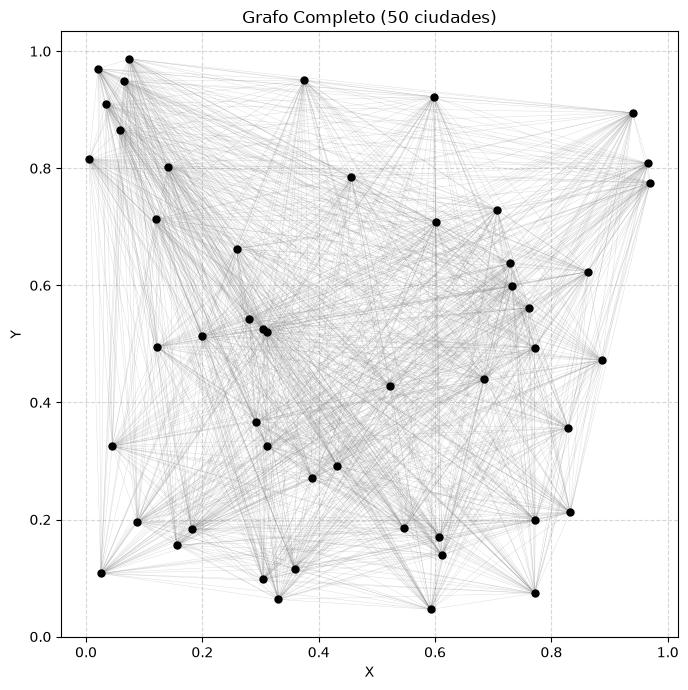

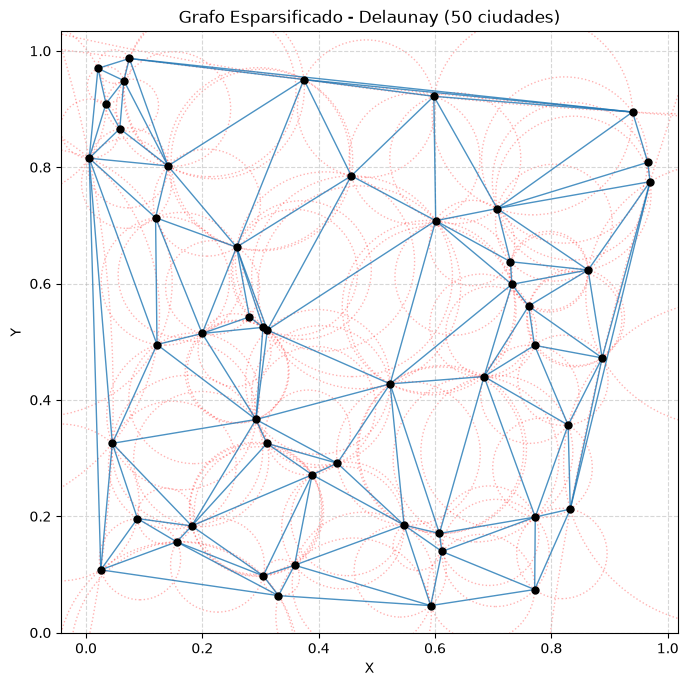

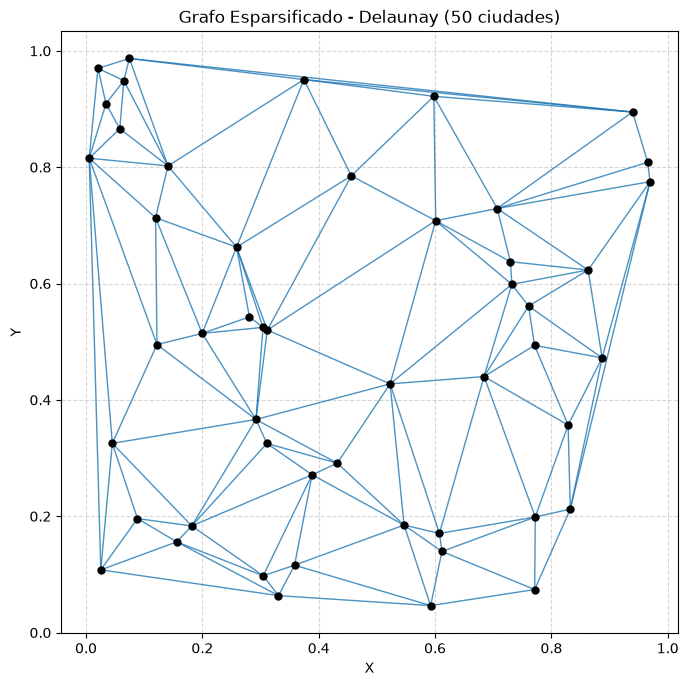

In [1]:
from instances.instances import generate_instances

instances = generate_instances(filename="TSP50.pkl", instance_count=1000, cities=50, seed=42)

# Grafo completo de ciudades
instances[0].plot()

# Grafo esparsificado con circunferencias circunscritas
instances[0].plot_sparse_graph(show_circumcircles=True)

# Grafo esparsificado final
instances[0].plot_sparse_graph()

Una vez listas las instancias, procedemos a generar el conjunto de datos para entrenar el modelo. El adaptador `SparseInputAdapter` simplemente se encarga de recuperar la matriz de adyacencia precalculada (producto de la esparsificación de Delaunay) y formatearla como una entrada válida para la red. Utilizamos el parámetro `sparse=True` para indicarle al entorno que debe esparsificar las instancias previamente a la consolidación del dataset.

In [2]:
from data.generation import generate_train_data
from data.adapters.input.sparse import SparseInputAdapter
from data.adapters.output.default import DefaultOutputAdapter

input_config = (SparseInputAdapter, 50)
output_config = (DefaultOutputAdapter, 50)

generate_train_data(
    instance_file="TSP50.pkl", 
    data_filename="train_data.h5", 
    input_adapter_config=input_config, 
    output_adapter_config=output_config,
    size=5000,
    sparse=True
)

Datos guardados en: /home/oscar/Escritorio/TSP-Framework/data/train_data.h5 (Tamaño: 5000)


## Entrenamiento

Por simplicidad, trabajaremos sobre la arquitectura base Glimpse. Como ahora integramos una matriz de adyacencia, solo necesitamos realizar un ajuste menor en el encoder: aplicar una máscara para que el mecanismo de atención se enfoque exclusivamente en las ciudades conectadas por el grafo esparsificado. De este modo, logramos que el modelo construya una representación más limpia y fuertemente ligada a la topología local del problema.

In [3]:
def encode(self, coords, visited, num_cities, adj_matrix):
    B, max_cities, _ = coords.shape
    device = coords.device

    pad_mask = self._get_pad_mask(max_cities, num_cities, device)
    enc_input = self.encoder_input_layer(coords)
    
    # El Encoder usa la matriz de Delaunay para aprender features locales
    src_mask = (~adj_matrix).repeat_interleave(self.num_heads, dim=0)
    
    memory = self.encoder(enc_input, mask=src_mask, src_key_padding_mask=pad_mask) 

    return memory

A continuación, inicializamos la arquitectura y realizamos el entrenamiento.

In [5]:
from data.preprocessing import load_dataset, split_dataset

train_file, val_file = split_dataset("train_data.h5", 4000)

train_dataset = load_dataset(train_file)
val_dataset = load_dataset(val_file)

from models.sparse import TSPTransformer

# Parámetros del modelo
input_dim = 2
embed_dim = 64
num_heads = 4
num_encoder_layers = 2
num_glimpses = 2
dropout = 0.1

# Crear modelo
model = TSPTransformer(
    input_dim=input_dim,
    embed_dim=embed_dim,
    num_heads=num_heads,
    num_encoder_layers=num_encoder_layers,
    num_glimpses=num_glimpses,
    dropout_rate=dropout,
)

from training.sl import sl_train, LRConfig
from training.metrics import CrossEntropyLoss, Accuracy

model = sl_train(
    model=model,
    epochs=10,
    train_set=train_dataset,
    val_set=val_dataset,
    batch_size=64,
    lr_config=LRConfig(value=1e-4),
    loss_fn=CrossEntropyLoss(),
    metrics=[Accuracy()],
    metrics_filename="sparse_metrics.txt"
)

Cargando dataset original: /home/oscar/Escritorio/TSP-Framework/data/train_data.h5
Guardando Train puro (4000 muestras) en: train_data_train.h5
Guardando Val puro (1000 muestras) en: train_data_val.h5
Dataset train_data_train.h5 cargado con 4000 muestras.
Dataset train_data_val.h5 cargado con 1000 muestras.
** Usando dispositivo: cpu

Epoch 1/10
    Train CrossEntropy: 2.1168 | Val CrossEntropy: 1.4368
    Accuracy: 60.50%
Epoch 2/10
    Train CrossEntropy: 1.4073 | Val CrossEntropy: 1.1251
    Accuracy: 69.70%
Epoch 3/10
    Train CrossEntropy: 1.1020 | Val CrossEntropy: 0.9067
    Accuracy: 76.70%
Epoch 4/10
    Train CrossEntropy: 0.9714 | Val CrossEntropy: 0.8230
    Accuracy: 77.00%
Epoch 5/10
    Train CrossEntropy: 0.9017 | Val CrossEntropy: 0.7756
    Accuracy: 79.00%
Epoch 6/10
    Train CrossEntropy: 0.8517 | Val CrossEntropy: 0.7393
    Accuracy: 79.20%
Epoch 7/10
    Train CrossEntropy: 0.8198 | Val CrossEntropy: 0.7196
    Accuracy: 80.70%
Epoch 8/10
    Train CrossEntropy

# Validación

Realizamos una validación simple para evaluar el desempeño de esta técnica. Cabe decir que debemos esparsificar previamente el grafo de ciudades antes de pasar los datos al modelo, al igual como lo hicimos previamente para la generación de datos.

In [ ]:
from solvers.eval import evaluate
from data.adapters.input.sparse import SparseInputAdapter

# 1. Definimos la misma configuración del adaptador que usamos en entrenamiento
input_config = (SparseInputAdapter, 50)

# 2. Ejecutamos la evaluación paralela sobre el conjunto de prueba 
model_sols, ort_sols = evaluate(
    model=model,
    instance_file="benchmarks/B50.pkl",
    input_adapter_config=input_config,
    num_workers=None,  # Utiliza todos los núcleos de CPU disponibles
    sparse=True
)

Iniciando evaluación conjunta de 100 instancias con 12 workers...

RESULTADOS DE LA VALIDACIÓN
Costo promedio Modelo:   6.46
Costo promedio OR-Tools: 5.82
Gap de optimalidad:      10.99% ± 5.99%

